In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression 
from sklearn.linear_model import LogisticRegression 

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import matplotlib.pyplot as plt
import pandas as pd
df=pd.read_csv('cashless_claim_prediction_dataset (1).csv')
df

,claim_id,patient_id,hospital_id,claim_submitted_date,age,gender,city_tier,bmi,smoker_flag,comorbidity_score,...,room_rent_limit_per_day,copay_percent,deductible_amount,waiting_period_applicable_flag,claimed_amount,room_charges,doctor_fees,medicine_charges,document_quality_score,approved_amount
0,CLM00003551,PAT000616,HSP0197,2024-08-24,62,Female,3.0,NaN,0.0,1,...,3915.0,10,10000,0,50974,22119,7975,10083,100.0,20662
1,CLM00004880,PAT001780,HSP0151,2024-04-11,38,Male,2.0,29.0,0.0,0,...,5077.0,0,0,0,57113,22148,13163,11712,74.0,35592
2,CLM00000982,PAT000934,HSP0230,2023-07-04,50,Male,2.0,28.9,0.0,1,...,13989.0,5,1000,0,51824,30179,8293,10292,61.0,48351
3,CLM00004997,PAT001322,HSP0077,2023-06-28,6,Male,1.0,NaN,0.0,2,...,2201.0,0,1000,0,59420,20321,8625,18688,64.0,35995
4,CLM00001759,PAT001541,HSP0114,2025-01-12,58,Male,1.0,23.1,0.0,2,...,1500.0,20,30000,0,105636,38276,23423,22119,96.0,31538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CLM00001444,PAT000312,HSP0060,2024-02-28,33,Male,1.0,31.1,0.0,1,...,3812.0,5,10000,0,44763,15723,6485,9841,52.0,19385
4996,CLM00003506,PAT000082,HSP0017,2023-10-04,28,Female,1.0,25.7,0.0,3,...,1500.0,30,2000,0,63330,22358,15588,13009,74.0,25669
4997,CLM00003374,PAT000823,HSP0164,2023-11-21,64,Male,1.0,24.1,0.0,3,...,1500.0,10,2000,0,122105,55007,25200,28427,55.0,72412
4998,CLM00003850,PAT001755,HSP0197,2024-01-17,36,Male,1.0,27.4,0.0,2,...,1500.0,30,30000,0,115131,46046,27583,23221,72.0,25870


In [33]:
df.isnull().sum()

claim_id                             0
patient_id                           0
hospital_id                          0
claim_submitted_date                 0
age                                  0
gender                               0
city_tier                            0
bmi                                  0
smoker_flag                          0
comorbidity_score                    0
prior_claim_count_2yr                0
prior_claim_amount_2yr               0
admission_type                       0
treatment_type                       0
diagnosis_category                   0
severity_level                       0
procedure_count                      0
procedure_complexity_score           0
icu_days                             0
length_of_stay_days                  0
pre_existing_disease_flag            0
hospital_type                        0
hospital_tier                        0
network_hospital_flag                0
hospital_historical_approval_rate    0
hospital_billing_index   

In [32]:
# Numerical → Median
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [36]:
df.duplicated().sum()

np.int64(0)

In [35]:
df.drop_duplicates(inplace=True)

<Axes: xlabel='approved_amount'>

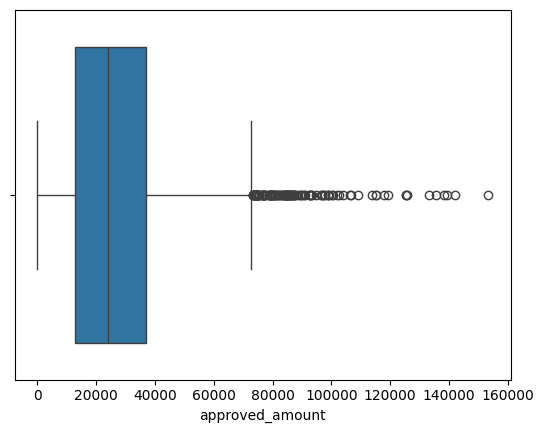

In [41]:
sns.boxplot(x='approved_amount',data=df)

<Axes: >

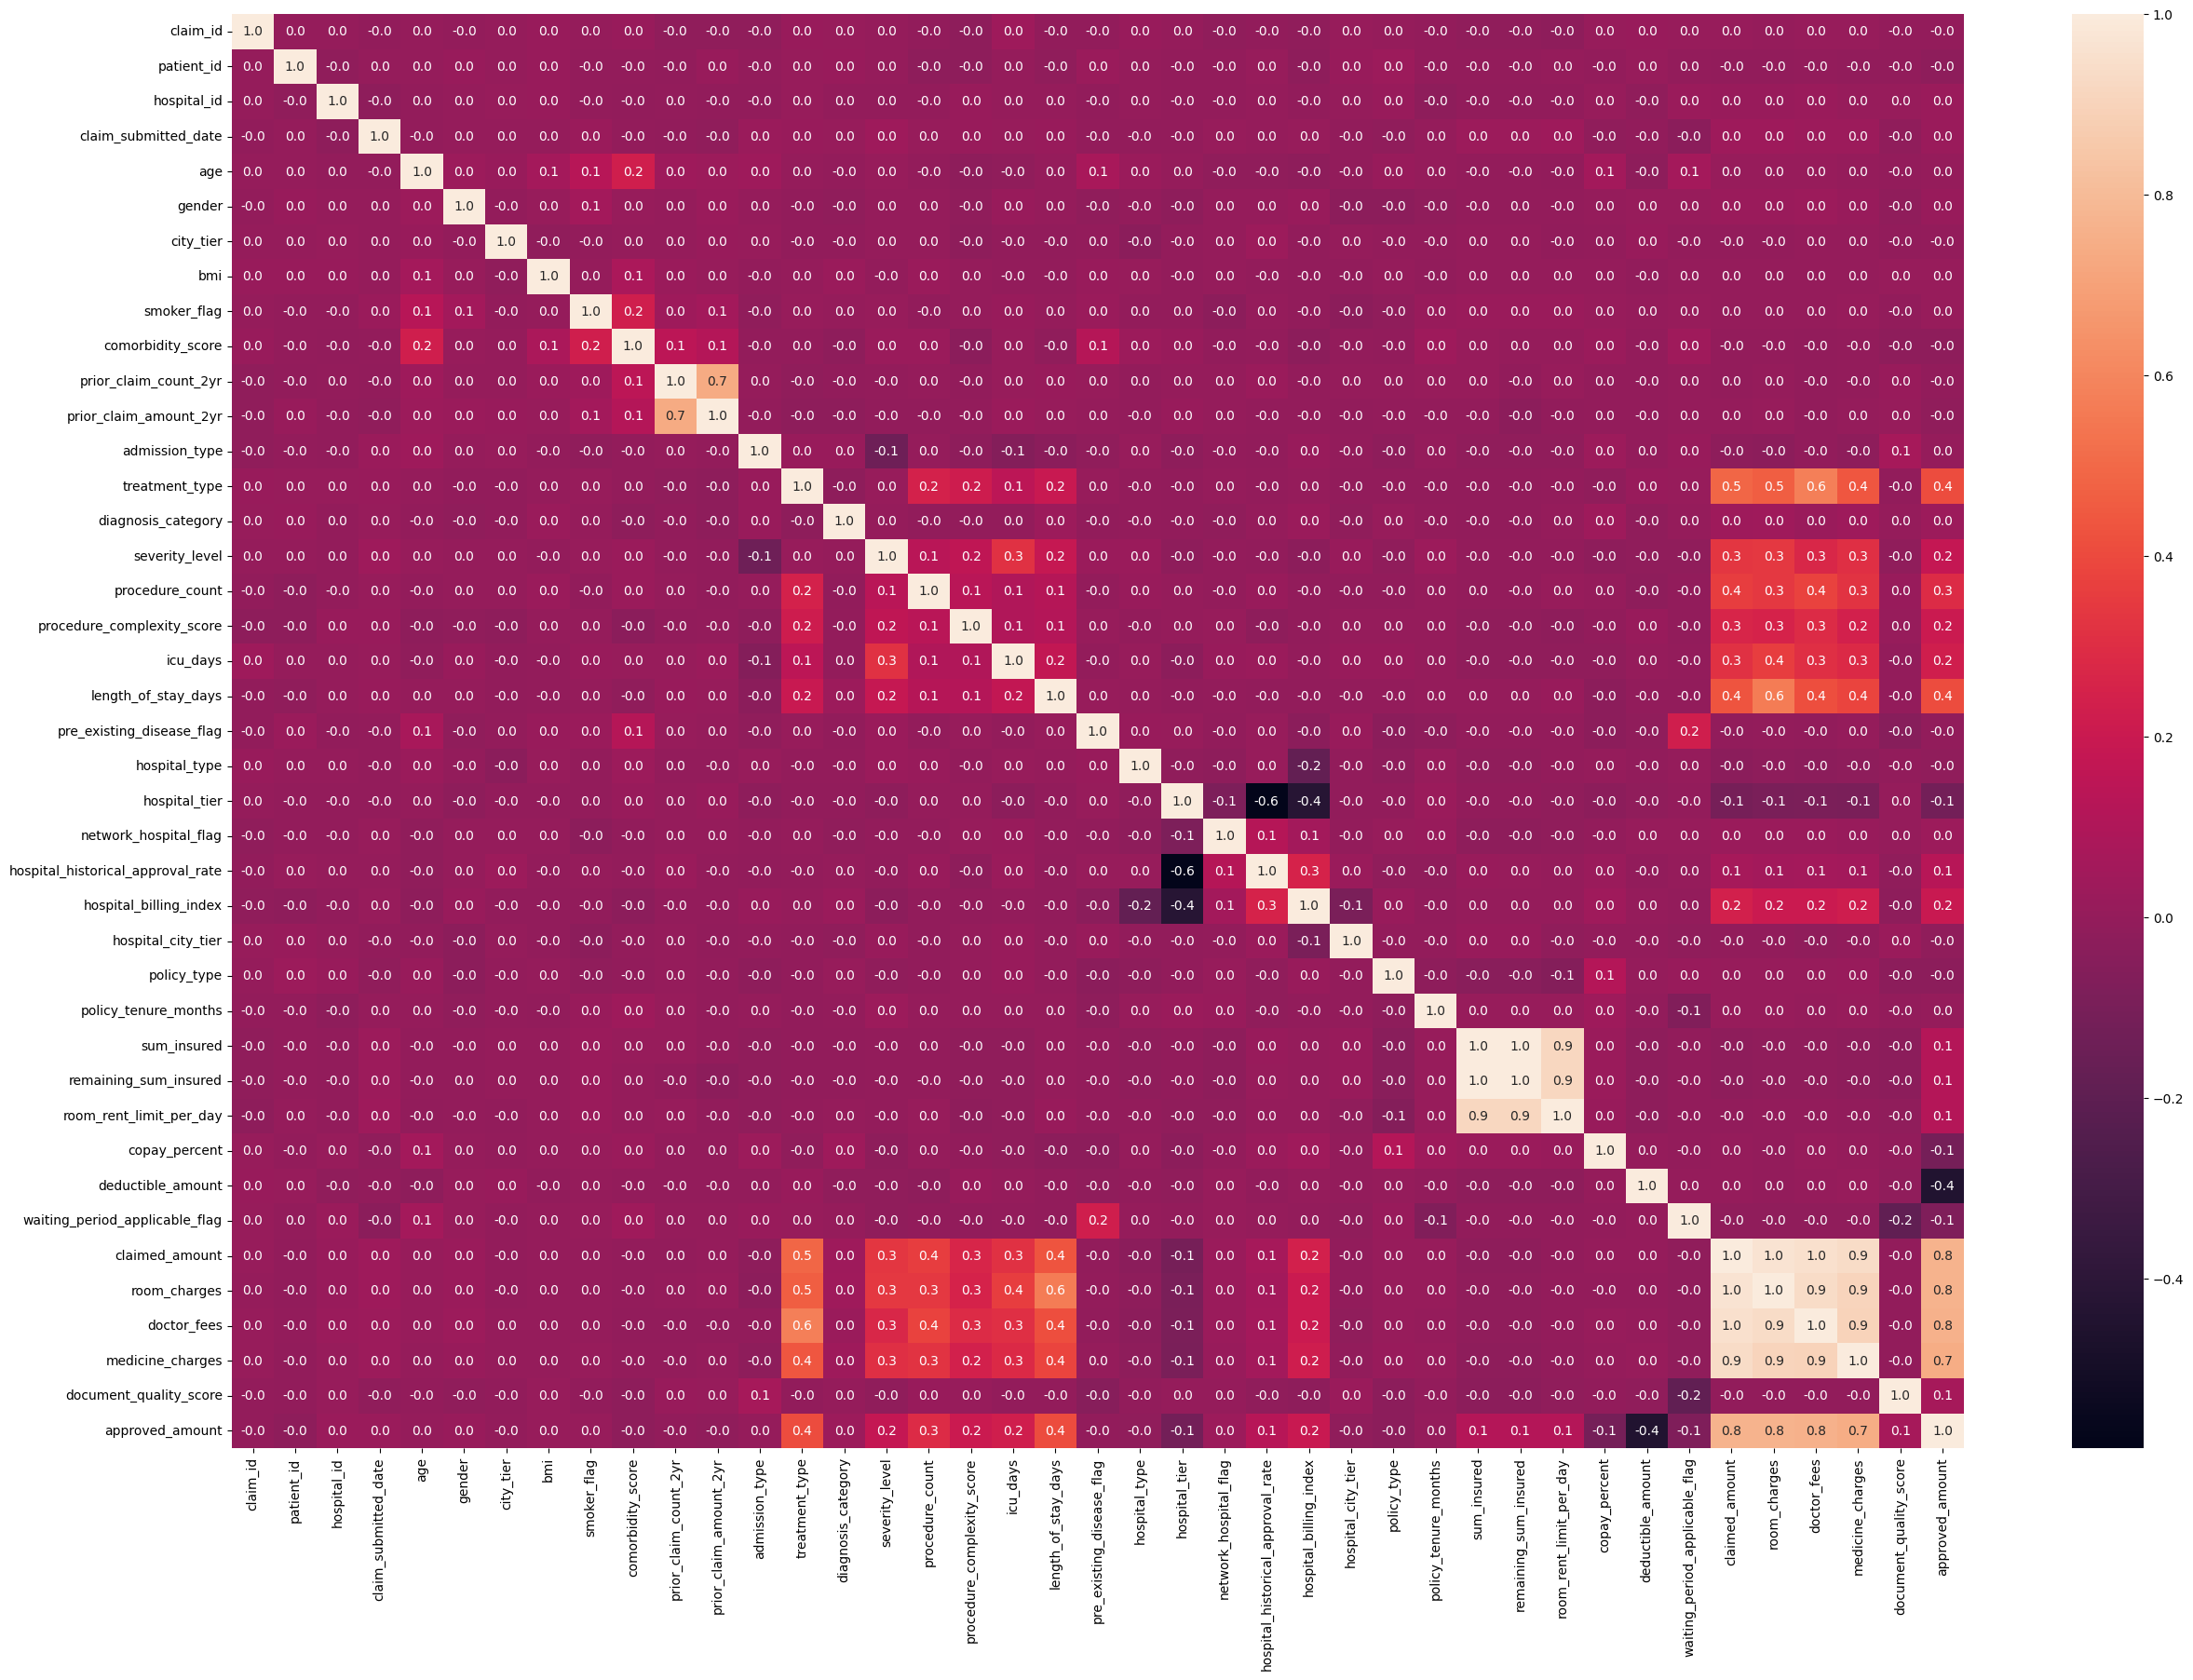

In [50]:
plt.figure(figsize=(30,20))
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,fmt='.1f')

In [51]:
df=df.drop(columns=['doctor_fees','room_charges'])
df.info

<bound method DataFrame.info of       claim_id  patient_id  hospital_id  claim_submitted_date  age  gender  \
0         3481         535          196                   595   62       1   
1         4785        1572          150                   463   38       3   
2          963         829          229                   183   50       3   
3         4900        1175           76                   177    6       3   
4         1719        1368          113                   735   58       3   
...        ...         ...          ...                   ...  ...     ...   
4994      3921          76           92                   888   57       1   
4995      1409         271           59                   421   33       3   
4996      3437          68           16                   275   28       1   
4997      3307         724          163                   322   64       3   
4999      3321         859          243                   122   21       1   

      city_tier   bmi  smoker_f

In [60]:
for i in df.select_dtypes(include=['object']).columns:
    print(i)
    l=LabelEncoder()                                           # to convert categorial data to numerical data(labelEncoder())
    df[i]=l.fit_transform(df[i])

In [61]:
x=df.drop('approved_amount',axis=1)
x
y=df['approved_amount']
x_train,x_test,y_train,y_test =train_test_split(x,y,train_size=0.2,random_state=42)

In [62]:
lin_reg = LinearRegression()
lin_reg.fit(x_train,y_train)


LinearRegression()

In [63]:
print(lin_reg.coef_)
print(lin_reg.intercept_)


[ 5.41828341e-02 -1.05836516e-01 -1.40967616e+00 -1.07256898e+00
 -1.34334163e+01  3.70752516e+01  4.12729428e+02  3.32694891e+01
  8.75099504e+02 -7.96009395e+01 -2.50030700e+02  8.29913954e-03
  1.17399610e+03  1.05142199e+03 -1.27059736e+02 -1.37784695e+03
  2.32724483e+02  7.73721407e+01  7.13558239e+01  7.43130732e+02
 -1.49204337e+02  3.23534889e+02 -8.77712189e+02  8.42219078e+02
  7.26866254e+03  2.64934154e+03 -7.52151451e+02 -6.10326558e+02
  1.22581132e+01 -3.22244317e-02  3.72709381e-02  1.05347248e-01
 -1.54222986e+02 -7.64812552e-01 -2.35442212e+03  2.77537385e-01
  7.28766501e-01  8.88075077e+01]
-9537.224805047259


In [64]:
y_pred = lin_reg.predict(x_test) # 20% of independent value
print(y_pred)# y_test actual y_pred-predicted value
#calculate mean squared error
mse = mean_squared_error(y_test , y_pred)
rmse = np.sqrt(mse)
mae= mean_absolute_error(y_test,y_pred)
r2score=r2_score(y_test,y_pred)
print('mean squared error:',mse)
print('root mean squared error:',rmse)
print('mean absolute error:',mae)
print('mean absolute error:',r2score)


[12177.04602219 50334.65860592 33662.68914714 ... 72849.53582423
 19669.88108617 -8644.94213415]
mean squared error: 55020704.061647564
root mean squared error: 7417.594223307687
mean absolute error: 4845.372983077891
mean absolute error: 0.8569678179404289


In [66]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()
dt.fit(x_train,y_train)
y_pred1=dt.predict(x_test)
train_score = dt.score(x_train,y_train) # train score
print(train_score)
mse1 = mean_squared_error(y_test , y_pred1)
rmse1 = np.sqrt(mse1)
mae1= mean_absolute_error(y_test,y_pred1)
r2score1=r2_score(y_test,y_pred1)
print()
print(mse1)
print(rmse1)
print(mae1)
print(r2score1)




1.0

97722772.57110092
9885.482920479955
6500.0028032619775
0.745959241414018


In [73]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()
rf.fit(x_train,y_train)
y_pred12=rf.predict(x_test)
train_score = dt.score(x_train,y_train) # train score
print(train_score)
mse12 = mean_squared_error(y_test , y_pred12)
rmse12 = np.sqrt(mse)
mae12= mean_absolute_error(y_test,y_pred12)
r2score12=r2_score(y_test,y_pred12)
print()
print(mse12)
print(rmse12)
print(mae12)
print(r2score12)


1.0

43480824.18010033
9760.791622577975
4365.414069826708
0.8869669651398844


In [77]:
from sklearn.ensemble import GradientBoostingRegressor


gradient_boosting_model = GradientBoostingRegressor()


gradient_boosting_model.fit(x_train, y_train)


gradient_boosting_predictions = gradient_boosting_model.predict(x_test)


In [78]:
mse4 = mean_squared_error(y_test, gradient_boosting_predictions)

r2gradient = r2_score(y_test, gradient_boosting_predictions)
r2gradient

0.929143351446879

In [79]:
import xgboost as xgb


xgboost_model = xgb.XGBRegressor()


xgboost_model.fit(x_train, y_train)
xgboost_predictions = xgboost_model.predict(x_test)

In [81]:
mse5 = mean_squared_error(y_test, xgboost_predictions)

r2xg = r2_score(y_test, xgboost_predictions)
r2xg

0.8974747657775879